In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/baseline-artifacts/thresholds.json
/kaggle/input/baseline-artifacts/df_resid.parquet
/kaggle/input/baseline-artifacts/df_pred.parquet
/kaggle/input/baseline-artifacts/df_wide.parquet
/kaggle/input/caf-dataset/CAF_sensors.dbf
/kaggle/input/caf-dataset/Hourly/Hourly/CAF141.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF019.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF209.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF007.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF397.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF237.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF205.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF125.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF139.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF095.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF201.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF215.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF079.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF231.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF275.

## 1.Data

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.neighbors import NearestNeighbors


In [3]:
df_wide = pd.read_parquet("/kaggle/input/baseline-artifacts/df_wide.parquet")
import geopandas as gpd

DBF_PATH = "/kaggle/input/caf-dataset/CAF_sensors.dbf"

gdf = gpd.read_file(DBF_PATH)



df_wide = df_wide.sort_index()
sensor_ids = df_wide.columns.tolist()

print(df_wide.shape)
# print(sensor_meta.head())


(66705, 10)


In [4]:
# ---------------------------
# FIX 1: Handle missing data
# ---------------------------
df_filled = df_wide.interpolate(limit_direction="both")
df_filled = df_filled.fillna(df_filled.mean())

assert not df_filled.isna().any().any(), "NaNs still present!"


In [5]:
# ---------------------------
# FIX 2: Normalize
# ---------------------------
X_np = df_filled.values.astype("float32")

mean = X_np.mean()
std  = X_np.std() + 1e-6

X_np = (X_np - mean) / std
X = torch.tensor(X_np, dtype=torch.float32)


In [6]:
def inject_bias(X, sensor, t0, t1, magnitude):
    X_fault = X.clone()
    X_fault[t0:t1, sensor] += magnitude
    return X_fault


In [7]:
# ---------------------------
# FAULT INJECTION (REAL)
# ---------------------------
sensor_idx = 2
t_start = 20000
t_end   = 20500
magnitude = 5.0   # normalized units

X_fault = inject_bias(X, sensor_idx, t_start, t_end, magnitude)


In [8]:
import torch

X = torch.tensor(X_np, dtype=torch.float32)

assert not torch.isnan(X).any()
assert torch.isfinite(X).all()


In [9]:
gdf.head()

,Location,Easting,Northing
0,CAF003,493383,5180586
1,CAF007,493511,5180568
2,CAF009,493575,5180573
3,CAF019,493247,5180590
4,CAF031,493628,5180612


In [10]:
sensor_meta = gdf[["Location", "Easting", "Northing"]].copy()
sensor_meta.head()


,Location,Easting,Northing
0,CAF003,493383,5180586
1,CAF007,493511,5180568
2,CAF009,493575,5180573
3,CAF019,493247,5180590
4,CAF031,493628,5180612


In [11]:
coords = (
    sensor_meta
    .set_index("Location")
    .loc[sensor_ids][["Easting", "Northing"]]
    .values
)

k = 4  # number of neighbors

nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
_, indices = nbrs.kneighbors(coords)

edge_index = []
for i in range(len(sensor_ids)):
    for j in indices[i][1:]:
        edge_index.append([i, j])

edge_index = torch.tensor(edge_index, dtype=torch.long).t()

print("Edge index shape:", edge_index.shape)


Edge index shape: torch.Size([2, 40])


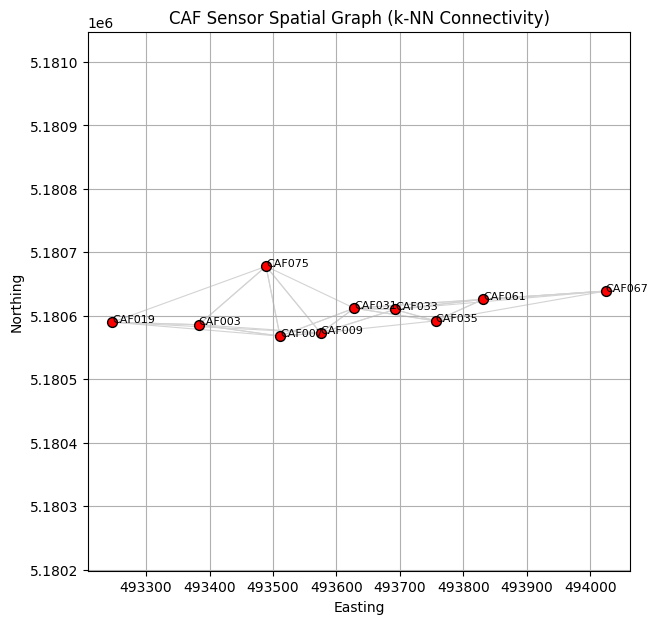

In [12]:
import matplotlib.pyplot as plt

# Extract coordinates
x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(7, 7))

# Plot edges
for i in range(edge_index.shape[1]):
    src = edge_index[0, i]
    dst = edge_index[1, i]
    plt.plot(
        [x[src], x[dst]],
        [y[src], y[dst]],
        color="lightgray",
        linewidth=0.8,
        zorder=1
    )

# Plot nodes
plt.scatter(
    x, y,
    c="red",
    s=50,
    edgecolors="black",
    zorder=2
)

# Optional: label sensors
for i, sensor in enumerate(sensor_ids):
    plt.text(x[i], y[i], sensor, fontsize=8)

plt.title("CAF Sensor Spatial Graph (k-NN Connectivity)")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.axis("equal")
plt.grid(True)
plt.show()


In [13]:
def edge_index_to_adj(edge_index, num_nodes):
    A = torch.zeros(num_nodes, num_nodes)
    for i, j in edge_index.t():
        A[i, j] = 1
        A[j, i] = 1
    A += torch.eye(num_nodes)  # self-loops
    A = A / A.sum(dim=1, keepdim=True)
    return A

A = edge_index_to_adj(edge_index, df_wide.shape[1])


In [14]:
window = 24

class SpatioTemporalDataset(Dataset):
    def __init__(self, data, window=24):
        self.X = data.values.astype("float32")
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.window]
        y = self.X[idx + self.window]
        return (
            torch.tensor(x),
            torch.tensor(y),
            idx   # ✅ return time index
        )


df_fault = pd.DataFrame(
    X_fault.cpu().numpy(),
    columns=df_filled.columns
)


dataset = SpatioTemporalDataset(df_filled, window=24)
dataset_fault = SpatioTemporalDataset(df_fault, window=24)
loader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)
loader_fault = DataLoader(dataset_fault, batch_size=32, shuffle=False)




## 2. Model

In [15]:
class SpatialGNN(nn.Module):
    def __init__(self, num_nodes, in_dim, out_dim, A):
        super().__init__()
        self.A = A
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        # x: (B, T, N, F)
        x = torch.einsum("ij,btjf->btif", self.A, x)
        return self.linear(x)


In [16]:
class ST_GNN_GRU(nn.Module):
    def __init__(self, num_nodes, hidden_dim, A):
        super().__init__()

        self.gnn = SpatialGNN(
            num_nodes=num_nodes,
            in_dim=1,
            out_dim=hidden_dim,
            A=A
        )

        self.gru = nn.GRU(
            input_size=hidden_dim * num_nodes,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Option C heads
        self.value_head = nn.Linear(hidden_dim, num_nodes)
        self.fault_head = nn.Linear(hidden_dim, num_nodes)

    def forward(self, x):
        # x: (B, T, N)
        B, T, N = x.shape
        x = x.unsqueeze(-1)              # (B, T, N, 1)

        x = self.gnn(x)                  # (B, T, N, H)
        x = x.reshape(B, T, -1)

        _, h = self.gru(x)
        h = h.squeeze(0)

        value = self.value_head(h)
        fault = torch.sigmoid(self.fault_head(h))

        return value, fault


In [17]:
model = ST_GNN_GRU(
    num_nodes=df_wide.shape[1],
    hidden_dim=32,
    A=A
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
mse_loss = nn.MSELoss()
bce_loss = nn.BCELoss(reduction="none")

lambda_fault = 0.01   # start small



In [18]:
fault_gt = torch.zeros_like(X)   # shape (T, N)
fault_gt[t_start:t_end, sensor_idx] = 1.0


In [19]:
print("NaNs in X:", np.isnan(X_np).any())
print("Infs in X:", np.isinf(X_np).any())


NaNs in X: False
Infs in X: False


## 3. Training

In [20]:
epochs = 10

for epoch in range(epochs):
    total_loss = 0.0

    for (x_fault, _, idx), (_, y_clean, _) in zip(loader_fault, loader):
        optimizer.zero_grad()

        # x_fault: faulty input
        y_hat, fault_prob = model(x_fault)

        # regress to CLEAN target
        L_reg = mse_loss(y_hat, y_clean)

        # fault supervision
        fault_gt_batch = fault_gt[idx + window]
        pos_weight = 20.0  # start with 20–50
        weights = torch.where(
            fault_gt_batch == 1,
            pos_weight,
            1.0
        )
        L_fault = (bce_loss(fault_prob, fault_gt_batch) * weights).mean()


        loss = L_reg + lambda_fault * L_fault
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader):.6f}")


Epoch 1, Loss: 0.005265
Epoch 2, Loss: 0.004192
Epoch 3, Loss: 0.004300
Epoch 4, Loss: 0.004265
Epoch 5, Loss: 0.004100
Epoch 6, Loss: 0.004135
Epoch 7, Loss: 0.003958
Epoch 8, Loss: 0.004020
Epoch 9, Loss: 0.003739
Epoch 10, Loss: 0.003721


In [21]:
model.eval()

all_residuals = []
all_predictions = []
all_targets = []

with torch.no_grad():
    for x, y,_ in loader_fault:
        y_hat, _ = model(x)      # y_hat: (B, N)
        res = torch.abs(y_hat - y)

        all_residuals.append(res)
        all_predictions.append(y_hat)
        all_targets.append(y)

all_residuals = torch.cat(all_residuals, dim=0)   # (T, N)
all_predictions = torch.cat(all_predictions, dim=0)
all_targets = torch.cat(all_targets, dim=0)


all_predictions_faulty = all_predictions
all_targets_faulty = all_targets
                        
print(all_residuals.shape)


torch.Size([66681, 10])


In [22]:
# ---- CLEAN INFERENCE ----
all_predictions_clean = []
all_targets_clean = []

with torch.no_grad():
    for x, y, _ in loader:
        y_hat, _ = model(x)
        all_predictions_clean.append(y_hat)
        all_targets_clean.append(y)

all_predictions_clean = torch.cat(all_predictions_clean, dim=0)
all_targets_clean = torch.cat(all_targets_clean, dim=0)


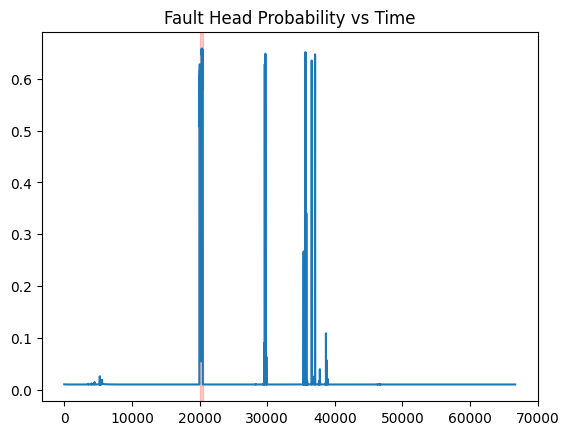

In [23]:
# ===========================
# INSERT FAULT PROBABILITY PLOT HERE
# ===========================
fault_probs = []

with torch.no_grad():
    for x, _, _ in loader_fault:
        _, fault_prob = model(x)
        fault_probs.append(fault_prob)

fault_probs = torch.cat(fault_probs, dim=0)

plt.plot(fault_probs[:, sensor_idx].cpu())
plt.axvspan(t_start, t_end, color="red", alpha=0.2)
plt.title("Fault Head Probability vs Time")
plt.show()
# ===========================

In [24]:
# ---- FAULT HEAD THRESHOLDING ----
tau = 0.2   # decision threshold
fault_flags_head = fault_probs.cpu().numpy() > tau   # (T, N)


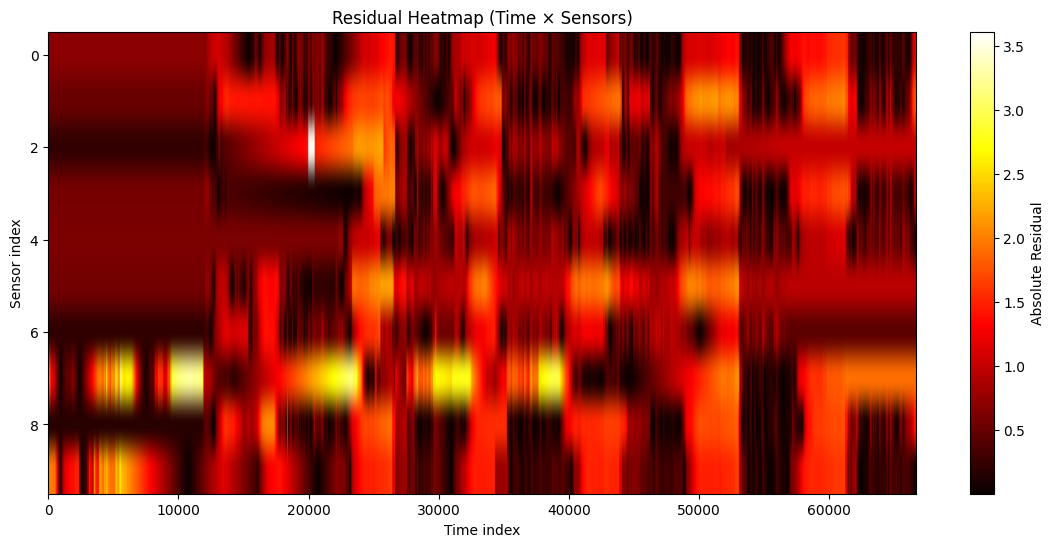

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.imshow(
    all_residuals.T.cpu().numpy(),
    aspect="auto",
    cmap="hot"
)
plt.colorbar(label="Absolute Residual")
plt.xlabel("Time index")
plt.ylabel("Sensor index")
plt.title("Residual Heatmap (Time × Sensors)")
plt.show()


## 4. Fault Detection

In [26]:
res_np = all_residuals.cpu().numpy()

sensor_median = np.median(res_np, axis=0)
sensor_mad = np.median(np.abs(res_np - sensor_median), axis=0)

thresholds = sensor_median + 4 * sensor_mad   # robust rule

print("Thresholds shape:", thresholds.shape)


Thresholds shape: (10,)


In [27]:
import scipy.signal as signal

fault_flags_resid = res_np > thresholds

# Hybrid: fault if BOTH agree
fault_flags_raw = fault_flags_resid | fault_flags_head



W = 100
K = 60
print("Residual flags %:", fault_flags_resid.mean() * 100)
print("Fault-head flags %:", fault_flags_head.mean() * 100)
print("Raw flags %:", fault_flags_raw.mean() * 100)
print("Raw fault window:",
      fault_flags_raw[t_start-50:t_end+50, sensor_idx].mean())

fault_flags_persisted = np.zeros_like(fault_flags_raw, dtype=bool)



for s in range(fault_flags_raw.shape[1]):
    conv = np.convolve(
        fault_flags_raw[:, s].astype(int),
        np.ones(W, dtype=int),
        mode="same"
    )
    fault_flags_persisted[:, s] = conv >= K

print("Fault %:", fault_flags_persisted.mean() * 100)
print("Fault window flags:",
      fault_flags_persisted[t_start-50:t_end+50, sensor_idx].mean())



Residual flags %: 1.668091360357523
Fault-head flags %: 0.06853526491804261
Raw flags %: 1.6769394580165262
Raw fault window: 0.835
Fault %: 1.568062866483706
Fault window flags: 0.8033333333333333


In [28]:
# ---- FAULT-TOLERANT RECONSTRUCTION (LOCF FIXED) ----
fault_tolerant_output = all_targets_faulty.clone()

for s in range(fault_flags_persisted.shape[1]):
    # initialize with first non-fault value
    valid_idx = np.where(~fault_flags_persisted[:, s])[0]
    if len(valid_idx) == 0:
        continue

    last_good = all_targets_faulty[valid_idx[0], s]

    for t in range(fault_flags_persisted.shape[0]):
        if not fault_flags_persisted[t, s]:
            last_good = all_targets_faulty[t, s]
        else:
            fault_tolerant_output[t, s] = last_good
# --------------------------------------------


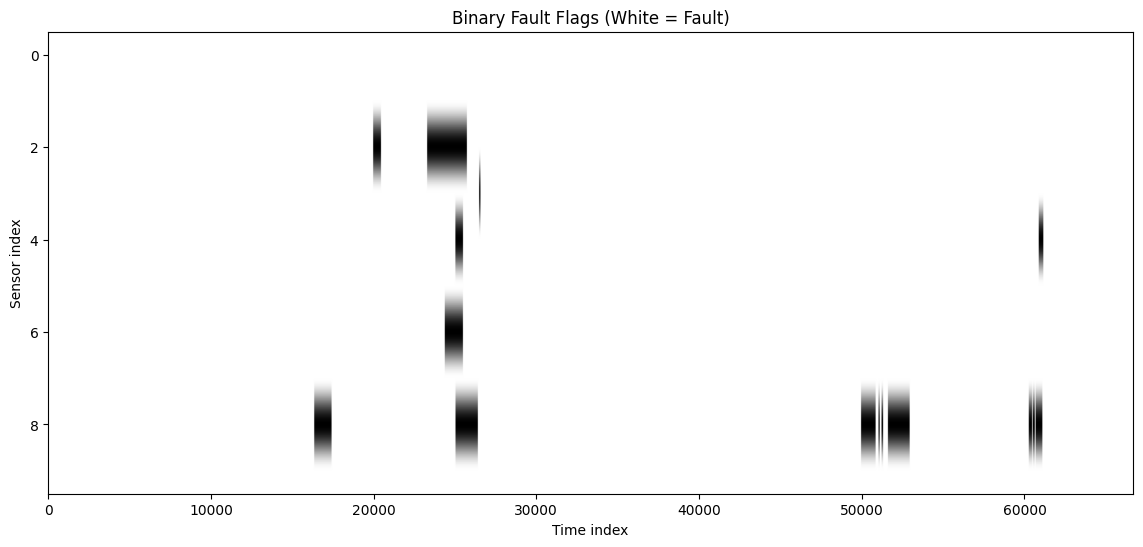

In [29]:
plt.figure(figsize=(14, 6))
plt.imshow(
    fault_flags_persisted.T,
    aspect="auto",
    cmap="gray_r"
)

plt.xlabel("Time index")
plt.ylabel("Sensor index")
plt.title("Binary Fault Flags (White = Fault)")
plt.show()


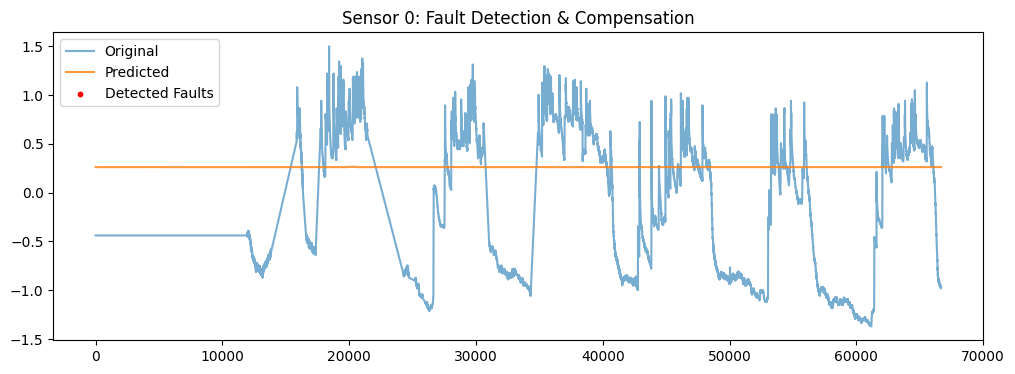

In [30]:
sensor_idx = 0   # or 0 / 1

plt.figure(figsize=(12, 4))
plt.plot(all_targets[:, sensor_idx].cpu(), label="Original", alpha=0.6)
plt.plot(all_predictions[:, sensor_idx].cpu(), label="Predicted", alpha=0.8)

# ---- ADD THIS HERE ----
idx = sensor_idx
mask = fault_flags_persisted[:, idx]

plt.scatter(
    np.where(mask)[0],
    all_targets[:, idx].cpu()[mask],
    color="red",
    s=10,
    label="Detected Faults"
)
# ----------------------

plt.legend()
plt.title(f"Sensor {sensor_idx}: Fault Detection & Compensation")
plt.show()


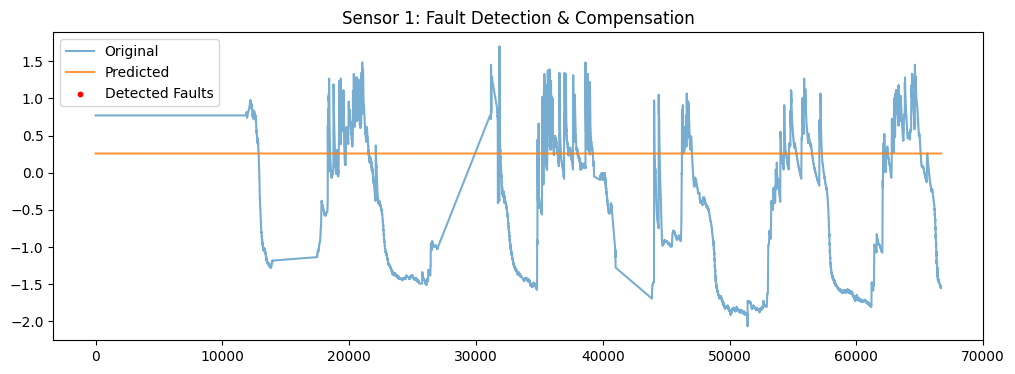

In [31]:
sensor_idx = 1   # or 0 / 1

plt.figure(figsize=(12, 4))
plt.plot(all_targets[:, sensor_idx].cpu(), label="Original", alpha=0.6)
plt.plot(all_predictions[:, sensor_idx].cpu(), label="Predicted", alpha=0.8)

# ---- ADD THIS HERE ----
idx = sensor_idx
mask = fault_flags_persisted[:, idx]

plt.scatter(
    np.where(mask)[0],
    all_targets[:, idx].cpu()[mask],
    color="red",
    s=10,
    label="Detected Faults"
)
# ----------------------

plt.legend()
plt.title(f"Sensor {sensor_idx}: Fault Detection & Compensation")
plt.show()


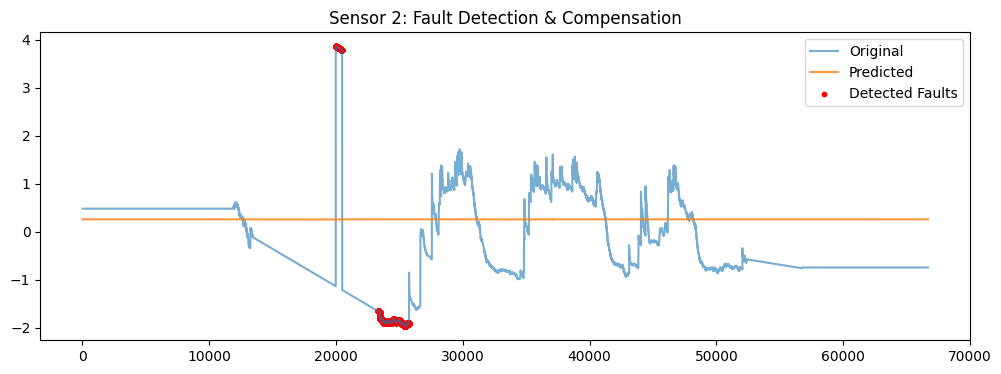

In [32]:
sensor_idx = 2   # or 0 / 1

plt.figure(figsize=(12, 4))
plt.plot(all_targets[:, sensor_idx].cpu(), label="Original", alpha=0.6)
plt.plot(all_predictions[:, sensor_idx].cpu(), label="Predicted", alpha=0.8)

# ---- ADD THIS HERE ----
idx = sensor_idx
mask = fault_flags_persisted[:, idx]

plt.scatter(
    np.where(mask)[0],
    all_targets[:, idx].cpu()[mask],
    color="red",
    s=10,
    label="Detected Faults"
)
# ----------------------

plt.legend()
plt.title(f"Sensor {sensor_idx}: Fault Detection & Compensation")
plt.show()


In [33]:
# ---- RMSE EVALUATION (ALIGNED & CORRECT) ----
min_len = min(
    all_targets_faulty.shape[0],
    all_targets_clean.shape[0],
    fault_tolerant_output.shape[0]
)

rmse_clean = torch.sqrt(
    torch.mean(
        (all_predictions_clean[:min_len] - all_targets_clean[:min_len]) ** 2
    )
)

rmse_faulty = torch.sqrt(
    torch.mean(
        (all_targets_faulty[:min_len] - all_targets_clean[:min_len]) ** 2
    )
)

min_len = min(
    fault_tolerant_output.shape[0],
    all_targets_clean.shape[0]
)

rmse_comp = torch.sqrt(
    torch.mean(
        (fault_tolerant_output[:min_len] - all_targets_clean[:min_len]) ** 2
    )
)


print("RMSE clean:", rmse_clean.item())
print("RMSE faulty:", rmse_faulty.item())
print("RMSE compensated:", rmse_comp.item())
# --------------------------------------------


RMSE clean: 0.05948827043175697
RMSE faulty: 1.0316452980041504
RMSE compensated: 1.0285624265670776
